In [1]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt

In [26]:
dataset_path = "./dataset.zarr"
ds = xr.open_zarr(dataset_path)

print(ds)

<xarray.Dataset>
Dimensions:    (latitude: 64, longitude: 128, time: 92040)
Coordinates:
  * latitude   (latitude) float64 -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
  * longitude  (longitude) float64 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
  * time       (time) datetime64[ns] 1959-01-02 ... 2021-12-31T18:00:00
Data variables:
    q700       (time, longitude, latitude) float32 dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
    t2m        (time, longitude, latitude) float32 dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
    t850       (time, longitude, latitude) float32 dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
    ws10       (time, longitude, latitude) float32 dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
    z500       (time, longitude, latitude) float32 dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
Attributes:
    long_name:      Geopotential
    short_name:     z
    standard_name:  geopotential
    units:          m**2 s**-2


In [27]:
z500_np = ds["z500"].values
t850_np = ds["t850"].values
q700_np = ds["q700"].values
t2m_np = ds["t2m"].values
ws10_np = ds["ws10"].values

merged_np = np.stack([z500_np, t850_np, q700_np, t2m_np, ws10_np], axis=1)

print(merged_np.shape)


(92040, 5, 128, 64)


In [28]:
size = merged_np.shape[0]
train_size = int(size * 0.8)
val_size = int(size * 0.1)
test_size = size - train_size - val_size

train_data = merged_np[:train_size]
val_data = merged_np[train_size:train_size + val_size]
test_data = merged_np[train_size + val_size:]

print(train_data.shape)
print(val_data.shape)
print(test_data.shape)

(73632, 5, 128, 64)
(9204, 5, 128, 64)
(9204, 5, 128, 64)


In [29]:
# save to numpy memmap

train_memmap = np.memmap("train.memmap", dtype='float32', mode='w+', shape=train_data.shape)
train_memmap[:] = train_data[:]
del train_memmap

val_memmap = np.memmap("val.memmap", dtype='float32', mode='w+', shape=val_data.shape)
val_memmap[:] = val_data[:]
del val_memmap

test_memmap = np.memmap("test.memmap", dtype='float32', mode='w+', shape=test_data.shape)
test_memmap[:] = test_data[:]
del test_memmap

In [10]:
# load memmap

data = np.memmap("test.memmap", dtype='float32', mode='r').reshape(-1, 5, 128, 64)
print(data.shape)


(9204, 5, 128, 64)


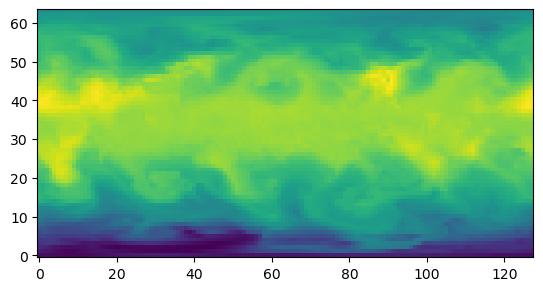

In [11]:
plt.imshow(data[0, 1].T, origin='lower')